## Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset and define Theme

In [2]:
sns.set_theme(style="whitegrid")

df = pd.read_json('./dataset_quality.jsonl', lines=True)
print(df.shape)
df.head()

(257, 7)


,before,after,refactor_type,repo,commit_sha,file,diff_lines
0,def digest_block_header(message: Message) -> d...,def digest_block_header(message: Message) -> F...,general,zulip/zulip,b516602ef087067c7342bf37a52697e2619a3558,zerver/lib/email_notifications.py,7
1,def build_message_list(\n user: UserProfile...,def build_message_list(\n user: UserProfile...,deduplicate,zulip/zulip,b516602ef087067c7342bf37a52697e2619a3558,zerver/lib/email_notifications.py,45
2,def test_soft_deactivated_user_multiple_stream...,def test_soft_deactivated_user_multiple_stream...,general,zulip/zulip,b516602ef087067c7342bf37a52697e2619a3558,zerver/tests/test_digest.py,6
3,"def rate_limit_entity(\n cls, entity_key: s...","def rate_limit_entity(\n cls, entity_key: s...",general,zulip/zulip,b956bdf6cc901fb4f5ca9c8d900cd66396087e5f,zerver/lib/rate_limiter.py,10
4,"def _create_set_parameters(self, rule_key: tup...","def _create_set_parameters(self, rule_key: tup...",general,oscal-compass/compliance-trestle,7ef431970fcfe5563895c1864c304e2221819ded,trestle/tasks/csv_to_oscal_cd.py,20


## Quality Metrics

# Chars
- `before_chars`: length of snippet before refactoring
- `after_chars`: length of snippet before refactoring
- `chars_delta`: number of changed chars
- `chars_delta_abs`: absolute value of `char_delta`

# Lines
- `before_lines`: Number of lines before refactor
- `after_lines`: Number of lines after refactor
- `lines_delta`: Number of changed lines
- `lines_delta_abs`: absolute value of `lines_delta`

In [3]:
df["before_chars"] = df["before"].str.len()
df["after_chars"] = df["after"].str.len()
df["chars_delta"] = df["after_chars"] - df["before_chars"]
df["chars_delta_abs"] = df["chars_delta"].abs()

df["lines_before"] = df["before"].str.count("\n") + 1
df["lines_after"] = df["after"].str.count("\n") + 1
df["lines_delta"] = df["lines_after"] - df["lines_before"]
df["lines_delta_abs"] = df["lines_delta"].abs()

print(df[["diff_lines", "before_chars", "after_chars", "chars_delta", "lines_before", "lines_after", "lines_delta", "lines_delta_abs"]].describe())


       diff_lines   before_chars    after_chars  chars_delta  lines_before  \
count  257.000000     257.000000     257.000000   257.000000    257.000000   
mean    19.762646    5003.031128    4973.972763   -29.058366    129.431907   
std     15.481658   24460.846374   24475.185297   594.743098    676.869711   
min      6.000000      62.000000      55.000000 -2867.000000      2.000000   
25%      8.000000     826.000000     795.000000  -145.000000     22.000000   
50%     16.000000    1616.000000    1552.000000    -3.000000     39.000000   
75%     25.000000    3649.000000    3582.000000   119.000000     90.000000   
max     78.000000  381911.000000  381938.000000  3483.000000  10679.000000   

        lines_after  lines_delta  lines_delta_abs  
count    257.000000   257.000000       257.000000  
mean     128.159533    -1.272374         7.723735  
std      677.159596    14.096893        11.851520  
min        2.000000   -72.000000         0.000000  
25%       20.000000    -4.000000     

## Histogram

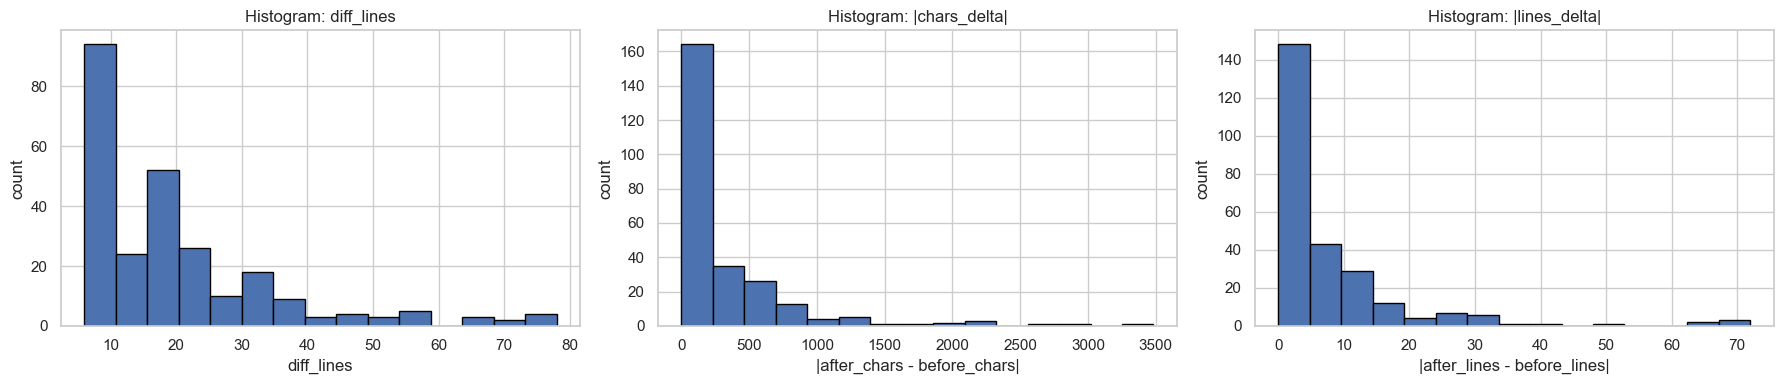

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["diff_lines"], bins=15, edgecolor="black")
axes[0].set_title("Histogram: diff_lines")
axes[0].set_xlabel("diff_lines")
axes[0].set_ylabel("count")

axes[1].hist(df["chars_delta_abs"], bins=15, edgecolor="black")
axes[1].set_title("Histogram: |chars_delta|")
axes[1].set_xlabel("|after_chars - before_chars|")
axes[1].set_ylabel("count")

axes[2].hist(df["lines_delta_abs"], bins=15, edgecolor="black")
axes[2].set_title("Histogram: |lines_delta|")
axes[2].set_xlabel("|after_lines - before_lines|")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()